In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path
import os
from shapely.ops import nearest_points
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString, Point
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString
from shapely.geometry import box


TARGET_CRS = "EPSG:5070"
RENDER_FRIENDLY_CRS = "EPSG:4326"
MILES_TO_METERS = 1609.344

os.chdir(Path(
    r"C:\Projects\geospatial_usa"
))

In [14]:
Centerline_Interstates = gpd.read_file("./maps/raw/IL_Interstate_Centerlines.geojson").to_crs(TARGET_CRS)
Centerline_USHighways = gpd.read_file("./maps/raw/IL_USHighways_Centerlines.geojson").to_crs(TARGET_CRS)
Centerline_StateHighways = gpd.read_file("./maps/raw/IL_StateHighways_Centerlines.geojson").to_crs(TARGET_CRS)

ILPlaces2022WithChicagoCommunity_AndCensus = gpd.read_file("./maps/raw/IL/ILPlaces2025_WithChicagoCommunityAreas.geojson").to_crs(TARGET_CRS)

# Supplemental
ILCounties = gpd.read_file("./maps/raw/counties_by_state/IL.geojson").to_crs(TARGET_CRS)

# View areas
ILCollarCountiesArea = gpd.read_file("./maps/raw/IL/IL_ChicagoCollarCountiesArea.geojson").to_crs(TARGET_CRS)
ChicagoArea = gpd.read_file("./maps/raw/Chicago/ChicagoArea.geojson").to_crs(TARGET_CRS)
ILMidStateArea = gpd.read_file("./maps/raw/IL/IL_MidStateArea.geojson").to_crs(TARGET_CRS)
ILSTLArea = gpd.read_file("./maps/raw/IL/IL_STLArea.geojson").to_crs(TARGET_CRS)
ILNorthern = gpd.read_file("./maps/raw/IL/IL_Northern.geojson").to_crs(TARGET_CRS)
IL_IATriCityArea = gpd.read_file("./maps/raw/IL/IL_IATriCityArea.geojson").to_crs(TARGET_CRS)

In [15]:
roads = Centerline_Interstates

roads['speed_mph'] = 80

roads["travel_time_hours"] = (
    roads["length_miles"]
    / roads["speed_mph"]
)

roads['origin'] = 'I'

In [16]:
G = nx.Graph()

for edge_id, row in roads.iterrows():

    geom = row.geometry

    # Atomic segments should be LineStrings
    if geom is None or geom.is_empty:
        continue

    if geom.geom_type != "LineString":
        continue

    coords = list(geom.coords)

    # Endpoints become graph nodes
    u = tuple(coords[0])
    v = tuple(coords[-1])

    # Add nodes
    G.add_node(
        u,
        x=u[0],
        y=u[1],
    )

    G.add_node(
        v,
        x=v[0],
        y=v[1],
    )

    # Add edge and preserve all original attributes
    edge_attributes = row.drop(
        labels="geometry"
    ).to_dict()

    edge_attributes["geometry"] = geom
    edge_attributes["edge_id"] = edge_id
    edge_attributes['origin'] = row['origin']

    G.add_edge(
        u,
        v,
        **edge_attributes,
    )

In [17]:
from shapely.ops import nearest_points

# --------------------------------------------------
# 1. PREPARE DATA
# --------------------------------------------------

places = (
    ILPlaces2022WithChicagoCommunity_AndCensus
    .copy()
)

# Keep the road GeoDataFrame separately
roads = roads.copy()

# Union all interstate road geometries into one
# Shapely geometry
road_system = roads.geometry.union_all()

print(
    "Road system type:",
    road_system.geom_type
)

# --------------------------------------------------
# 2. SNAP PLACE REPRESENTATIVE POINTS
# --------------------------------------------------

places["representative_point"] = (
    places.geometry.representative_point()
)

# 10 miles converted to meters
MAX_SNAP_DISTANCE_M = (
    10 * MILES_TO_METERS
)


def snap_place_to_road(
    place_polygon,
):

    nearest_place_point, nearest_road_point = (
        nearest_points(
            place_polygon,
            road_system,
        )
    )

    snap_distance_m = (
        nearest_place_point.distance(
            nearest_road_point
        )
    )

    if (
        snap_distance_m
        <= MAX_SNAP_DISTANCE_M
    ):

        return (
            nearest_road_point,
            snap_distance_m,
        )

    return (
        None,
        snap_distance_m,
    )

snap_results = (
    places["representative_point"]
    .apply(
        snap_place_to_road
    )
)

places["road_point"] = (
    snap_results.apply(
        lambda result: result[0]
    )
)

places["snap_distance_m"] = (
    snap_results.apply(
        lambda result: result[1]
    )
)

places["snap_distance_miles"] = (
    places["snap_distance_m"]
    / 1609.344
)

# --------------------------------------------------
# 3. CREATE POINT GEODATAFRAMES
# --------------------------------------------------

# Places that did not find an interstate within 10 miles
unsnapped_places = (
    places[
        places["road_point"].isna()
    ]
    .copy()
)

# Display unsnapped places using their representative point
unsnapped_places = (
    unsnapped_places
    .set_geometry(
        "representative_point"
    )
)

# Places that successfully snapped to an interstate
place_road_points = (
    places[
        places["road_point"].notna()
    ]
    .copy()
    .set_geometry(
        "road_point"
    )
)

print(
    "Total places:",
    f"{len(places):,}"
)

print(
    "Successfully snapped:",
    f"{len(place_road_points):,}"
)

print(
    "Could not snap within 10 miles:",
    f"{len(unsnapped_places):,}"
)

print(
    places[
        "snap_distance_miles"
    ].describe()
)

Road system type: MultiLineString
Total places: 897
Successfully snapped: 653
Could not snap within 10 miles: 244
count    897.000000
mean       7.871178
std        9.279587
min        0.002311
25%        1.445281
50%        4.234242
75%       10.934077
max       57.928842
Name: snap_distance_miles, dtype: float64


In [19]:
tolerance = 1  # feet EPSG:3435

buffered_roads = roads.copy()
buffered_roads["geometry"] = buffered_roads.geometry.buffer(tolerance)

check = gpd.sjoin(
    place_road_points[["road_point"]],
    buffered_roads[["geometry"]],
    predicate="within",
    how="left"
)

print(
    f"{check.index_right.notna().mean()*100:.2f}% within {tolerance} feet"
)

100.00% within 1 feet


C:\Users\Wayne\AppData\Local\Temp\ipykernel_59204\2243222704.py:6: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:5070

  check = gpd.sjoin(


In [22]:
import geopandas as gpd
import pandas as pd
import networkx as nx

from shapely.geometry import Point, LineString
from shapely.ops import split, snap


# --------------------------------------------------
# SPLIT ROADS AT PLACE POINTS
# --------------------------------------------------

roads_split = []

# tolerance for snapping to line (feet)
snap_tolerance = 1


for idx, road in roads.iterrows():

    line = road.geometry

    # places close to this road
    nearby_places = place_road_points[
        place_road_points.geometry.distance(line)
        <= snap_tolerance
    ]

    split_geom = line

    # split at each place point
    for point in nearby_places.geometry:

        split_geom = snap(
            split_geom,
            point,
            snap_tolerance
        )

        try:
            split_geom = split(
                split_geom,
                point
            )
        except:
            pass


    # save pieces
    if split_geom.geom_type == "GeometryCollection":

        for piece in split_geom.geoms:
            if piece.geom_type == "LineString":
                row = road.copy()
                row.geometry = piece
                roads_split.append(row)

    elif split_geom.geom_type == "MultiLineString":

        for piece in split_geom.geoms:
            row = road.copy()
            row.geometry = piece
            roads_split.append(row)

    else:
        row = road.copy()
        row.geometry = split_geom
        roads_split.append(row)



AtomicRoadsSplit = gpd.GeoDataFrame(
    roads_split,
    crs=TARGET_CRS
)


print(
    len(roads),
    "original edges"
)

print(
    len(AtomicRoadsSplit),
    "split edges"
)

437 original edges
524 split edges


In [24]:
import networkx as nx
from shapely.geometry import LineString, MultiLineString

# Undirected graph
G = nx.Graph()

for road_id, road in AtomicRoadsSplit.iterrows():

    geom = road.geometry

    # Skip missing or empty geometries
    if geom is None or geom.is_empty:
        continue

    # Atomic roads should normally be LineStrings
    if isinstance(geom, MultiLineString):
        parts = list(geom.geoms)
    else:
        parts = [geom]

    for part_num, line in enumerate(parts):

        # Get the two endpoint coordinates
        start = tuple(line.coords[0])
        end = tuple(line.coords[-1])

        # Add the edge with miles as the routing weight
        G.add_edge(
            start,
            end,
            road_id=road_id,
            part_num=part_num,
            origin=road['origin'],
            length_miles=road["length_miles"],
            travel_time_hours=road['travel_time_hours'],
            geometry=line,
        )

print(
    f"Graph has {G.number_of_nodes():,} nodes "
    f"and {G.number_of_edges():,} edges"
)

Graph has 369 nodes and 524 edges


In [25]:
def get_closest_vertex(
    point,
    G,
):
    """
    Return the closest graph vertex to a Shapely Point.

    Assumes graph node IDs are coordinate tuples:
    (x, y)
    """

    return min(
        G.nodes,
        key=lambda node: point.distance(
            Point(node)
        )
    )

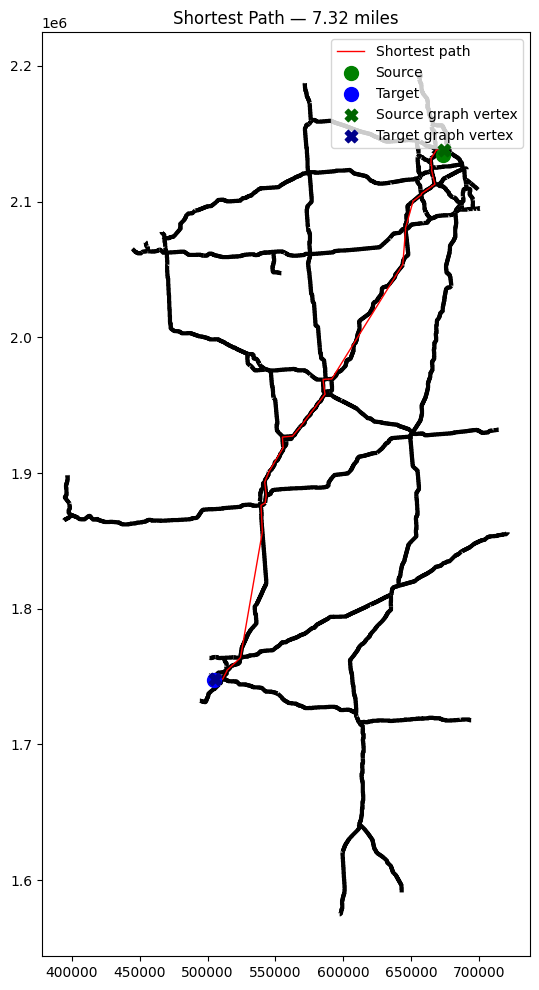

In [26]:
 # Find closest graph node to source

weight = "travel_time_hours"


source_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'DUNNING')
)].iloc[0]


target_point = ILPlaces2022WithChicagoCommunity_AndCensus[(
    (ILPlaces2022WithChicagoCommunity_AndCensus['PLACE_NAME'] == 'East St. Louis')
)].iloc[0]

source_node = get_closest_vertex(source_point.geometry.representative_point(), G)
target_node = get_closest_vertex(target_point.geometry.representative_point(), G)

# Run shortest path using edge mileage
route_nodes = nx.shortest_path(
    G,
    source=source_node,
    target=target_node,
    weight=weight,
)

route_miles = nx.shortest_path_length(
    G,
    source=source_node,
    target=target_node,
    weight=weight,
    )


import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

# Convert the ordered route nodes into a line
route_line = LineString(route_nodes)

# Plot
fig, ax = plt.subplots(
    figsize=(12, 12)
)

# Plot all atomic roads
AtomicRoadsSplit[
    (AtomicRoadsSplit['origin'] == 'I')
].plot(
    ax=ax,
    color="black",
    linewidth=3,
)

# Plot the shortest path
ax.plot(
    *route_line.xy,
    color="red",
    linewidth=1,
    label="Shortest path",
)

# Plot the original source and target representative points
ax.scatter(
    source_point.geometry.representative_point().x,
    source_point.geometry.representative_point().y,
    color="green",
    s=100,
    marker="o",
    label="Source",
    zorder=5,
)

ax.scatter(
    target_point.geometry.representative_point().x,
    target_point.geometry.representative_point().y,
    color="blue",
    s=100,
    marker="o",
    label="Target",
    zorder=5,
)

# Plot the graph vertices used for routing
ax.scatter(
    source_node[0],
    source_node[1],
    color="darkgreen",
    s=80,
    marker="X",
    label="Source graph vertex",
    zorder=6,
)

ax.scatter(
    target_node[0],
    target_node[1],
    color="darkblue",
    s=80,
    marker="X",
    label="Target graph vertex",
    zorder=6,
)

ax.legend()

ax.set_title(
    f"Shortest Path — {route_miles:.2f} miles"
)

plt.show()